We are modelling the selling process of a company. They sell the company if they reach a strike price of K = 12000. The initial value of the company is $V_0 = 10000$, and for each day, the company makes a profit of $Y_i \sim N(\mu = -30, \sigma^2 = 100^2)$.

The company is dissolved if the value is $0$ or lower on the i'th day. The formal definition of the probability of selling on the n'th day is given by, the probability that the company value is greater than or equal to K on the n'th day, and that it has not been dissolved on any of the previous days. Let
$$V_i = V_0 + \sum_{j = 1}^i Y_j$$

$$p(n)_{sell} = P(V_n \geq K, \, \bigcap_{j = 1}^{n-1} ( 0 < V_j < K))  $$
Note that we can only sell the company once on the n'th day, thus the events are disjoint for all n from 1 to infinity. Thus we can write the probability of selling the company as
$$
p_{sell} = \sum_{n=1}^{\infty} p(n)_{sell}
$$
We note that this is a Markov process, as the conditional probability of selling on the n'th day, given that we have not sold or dissolved the company on any of the previous days, is only dependent on the value of the company on the (n-1)'th day. Thus we can write
$$
P(V_n | V_1, V_2, ..., V_{n-1} ) = P(V_n | V_{n-1})
$$
We now turn to estimating the probability of selling the company by crude montecarlo.

In [148]:
import numpy as np


N = 10**3
K = 12000
V0 = 11000
def crude_montecarlo(N, K, V0, max_runs = 10000):
    # Simulate the selling process for N companies
    sell_count = 0
    bankrupt_count = 0
    simulation_lengths = []

    for _ in range(1, N):
        runs = 0
        V = V0
        while V > 0 and V < K: # and runs < max_runs :
            # Simulate the profit for the day
            Y = np.random.normal(-30, 100)
            V += Y
            runs += 1

        sell_count += (1 if V >= K else 0)

        simulation_lengths.append(runs)
    sell_rate = sell_count / N
    # Bernoulli process so variance is
    var_hat = sell_rate * (1 - sell_rate) / N
    return sell_rate, var_hat, simulation_lengths

crude_montecarlo(N, K, V0)

(0.0,
 0.0,
 [439,
  333,
  318,
  377,
  281,
  405,
  422,
  366,
  371,
  414,
  386,
  391,
  377,
  315,
  394,
  344,
  340,
  355,
  402,
  284,
  331,
  394,
  370,
  326,
  272,
  406,
  373,
  308,
  370,
  489,
  350,
  360,
  448,
  357,
  424,
  306,
  507,
  434,
  435,
  309,
  433,
  393,
  402,
  362,
  384,
  391,
  510,
  341,
  376,
  335,
  460,
  357,
  374,
  422,
  295,
  366,
  352,
  338,
  315,
  315,
  351,
  279,
  395,
  396,
  416,
  400,
  464,
  347,
  381,
  341,
  388,
  432,
  337,
  352,
  348,
  439,
  350,
  333,
  370,
  369,
  411,
  387,
  439,
  396,
  390,
  260,
  371,
  291,
  450,
  263,
  420,
  389,
  377,
  361,
  325,
  426,
  329,
  351,
  294,
  341,
  322,
  391,
  336,
  444,
  354,
  372,
  286,
  335,
  597,
  445,
  322,
  473,
  314,
  352,
  282,
  409,
  362,
  373,
  412,
  373,
  312,
  400,
  285,
  378,
  372,
  344,
  375,
  419,
  363,
  233,
  367,
  329,
  300,
  449,
  383,
  283,
  275,
  313,
  305,
  329,
  383,
 

Now we introduce importance sampling to speed up the simulation and reduce the variance of our estimate. The problem right now is that under the measure $f_Y$, where $Y \sim N(-30, 100^2)$, the probability of selling the company is very low, and thus we need a large number of simulations to get a good estimate. We can instead simulate under a different measure $g_Y$, where $Y \sim N(\mu, 100^2)$ for some $\mu > -30$. We can then use the likelihood ratio to correct for the change in measure. The likelihood ratio is given by
$$
L(Y) = \frac{f_Y(Y)}{g_Y(Y)}
$$
Now, for numerical stability, we cannot just choose a arbitrarily large $\mu$, as this will cause f_Y(Y) to be numerically zero with high probability, and thus the likelihood ratio will be numerically zero with high probability.

Note that our random variable $V_n$ is a function of the independent random variables $Y_1, Y_2, ..., Y_n$, and our function $H(X) = \mathbf{1}(p_0 + \sum X_i \geq K)$. Thus the likelihood of the joint distribution is given by the product of the individual likelihoods, since the $Y_i$'s are independent. Therefore, we can write the likelihood ratio as
$$
L(Y_1, Y_2, ..., Y_n) = \prod_{i=1}^{n} L(Y_i)
$$
This is utilized in the while loop, where we multiply the likelihood ratio for each day to get the joint likelihood ratio for the entire simulation.

In [149]:
def importance_montecarlo(N, K, V0, mu, max_runs = 10000):
    # Simulate the selling process for N companies
    sell_count = 0
    bankrupt_count = 0
    simulation_lengths = []
    sell_count = []

    def likelihood_ratio(y, mu_star):
        return np.exp(
            ((y - mu_star)**2 - (y + 30)**2) / (2 * 100**2)
        )

        return L
    for _ in range(0, N):
        runs = 0
        V = V0
        L = 1
        while V > 0 and V < K: # and runs < max_runs :
            # Simulate the from importance distribution
            Y = np.random.normal(mu, 100)
            # V is a function X = (Y1, Y2, ...,Yn) which are independent.
            # As such we can compute the joint liklihood as a product.
            L *= likelihood_ratio(Y, mu_star= mu)

            V += Y
            runs += 1
        if np.isclose(L, 0, atol=1e-16):
            print("Underflow Warning")
        sell_count.append(1 * L
                       if V >= K else
                       0)

        simulation_lengths.append(runs)
    var_hat = np.var(sell_count) / N
    sell_rate = np.sum(sell_count) / N
    return sell_rate, var_hat, simulation_lengths

l, s, iters = importance_montecarlo(N, K, V0, mu = 3000)

Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow Warning
Underflow 

In [156]:
mus = [10 + 3*k for k in range(10)]
results = []
for mu in mus:
    results.append(importance_montecarlo(N, K, V0, mu = mu))
import matplotlib.pyplot as plt
estimate, variance, simulation_lengths = zip(*results)

Underflow Warning


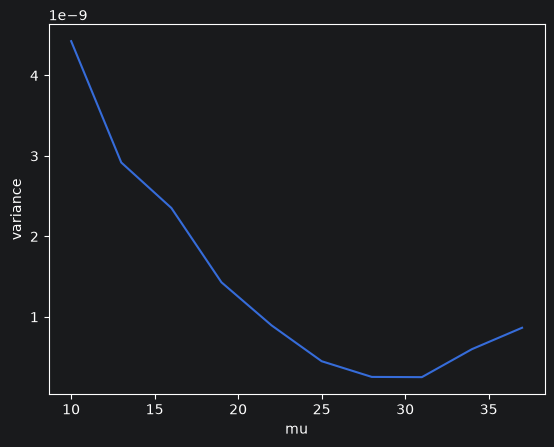

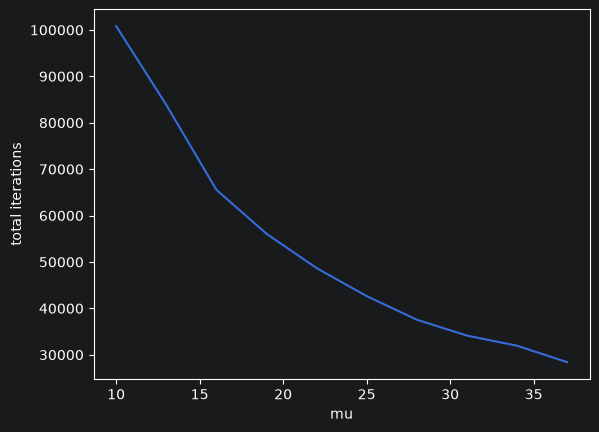

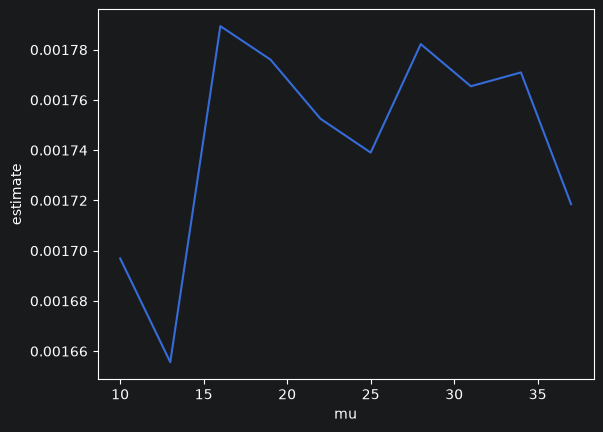

In [157]:
simulation_lengths = np.array([sum(s) for s in simulation_lengths])
plt.plot(mus, variance)
plt.xlabel('mu')
plt.ylabel('variance')
plt.show()

plt.plot(mus, simulation_lengths)
plt.xlabel('mu')
plt.ylabel('total iterations')
plt.show()
plt.plot(mus, estimate)
plt.xlabel('mu')
plt.ylabel('estimate')
plt.show()
